# Test PCA Pipeline

2/18/2026

Working on the PCA pipeline for functionality...

In [ ]:
import sparkles
import sparkles.data_proc as spca
import sparkles.data_calib as spcal

import re
import datetime
import sys
from astropy.io import fits
import numpy as np
from importlib import reload
from matplotlib import pyplot as plt

import sparkles.file_read as fr 

My goal for pulling an observation is just sending in the looky loo string to parse 

In [93]:
dark_dir = '/opt/MagAOX/calib/camwfs-dark/'
lab_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_10.000000_-45.000000__T20240330051127513106835.fits'
sky_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_595.000000_-45.000000__T20250420001026277139922.fits'
dir_spark_calib = "/home/eden/data/sparkPCA"
selfRM_filepath = "/opt/MagAOX/cacao/tweeter-vispyr/tweeter-vispyr-calibs/"

### Testing the lab calib system 

#### Pick calibration

In [ ]:
lab_str = "2025-12-03_042134_tau_ceti_lab_efc_unsats"
amp = 0.03
hz = 2000
sep = 22
ang = 18
# n files = 5000/6000
lab_dt, lab_obs = fr.dir_to_lookyloo(lab_str, target_name="tau_ceti")

In [ ]:
lab_str = "2025-12-01_053319_beta_pic_lab_efc"
# spark params need to be done by hand
sep = 22
amp = 0.02
ang = 45
hz = 2000
# n files = 5000/7000
lab_dt, lab_obs = fr.dir_to_lookyloo(lab_str, target_name="beta_pic")

In [ ]:
# WARNING! these aren't actually the lab cals we need
lab_str = "2025-11-30_035905_tau_ceti_efc_lab"
# spark params need to be done by hand
sep = 22
amp = 0.05
ang = 45
hz = 2000
# n files = 5000/7000
lab_dt, lab_obs = fr.dir_to_lookyloo(lab_str, target_name="tau_ceti")

In [ ]:
from sparkles.camwfs_dark import find_closest_camwfs_dark

# Auto-pick nearest camwfs dark from observation datetime(s)
dark_dir = "/opt/MagAOX/calib/camwfs-dark"

lab_dark_match = find_closest_camwfs_dark(lab_dt, dark_dir=dark_dir)
lab_dark = str(lab_dark_match.dark_path)
print("lab_dark:", lab_dark)
print("lab dark dt:", lab_dark_match.dark_dt_utc, "delta_s:", lab_dark_match.delta_seconds)

# Optional: set sky_dark if a sky datetime is already available in the notebook
if "sky_dt" in globals():
    sky_dark_match = find_closest_camwfs_dark(sky_dt, dark_dir=dark_dir)
    sky_dark = str(sky_dark_match.dark_path)
    print("sky_dark:", sky_dark)
    print("sky dark dt:", sky_dark_match.dark_dt_utc, "delta_s:", sky_dark_match.delta_seconds)

#### Run calibration

In [111]:
# STEP 1: load in 
reload(spcal)
calib = spcal.SparkCalibrate(dir_spark_calib, lab_dark, sep, ang, amp, hz)  

making directory for this calibration: /home/eden/data/sparkPCA/sep22_ang45_amp0.05_freq2000


In [112]:
# STEP 2: load the data
calib.set_data(lab_obs, lab_dt)

['0:03:35.256483 \n']


In [113]:
# STEP 3: generate the lab PCA
Z_KL, Z_KL_img, lab_avgs, timing_ar = calib.gen_lab_ref(n_lab=5000)

GENERATING REFERENCE PCA basis
Found 53 xrifs, total 27136 files
PULLING 5000 FILES
FILE no 10, n_start 0, n 5000, n_offset 0
XRIF index 0, no of files 10, len list 53


file n pull (5000, 120, 120)


In [114]:
# STEP 4: save the references to fits files
calib.save_reference()

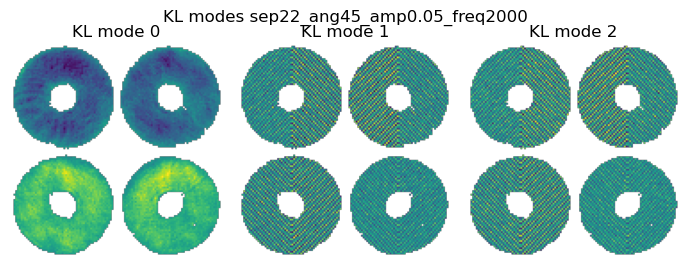

In [115]:
calib.show_pca_basis()

## TEST 1: check the base pull

#### Check the science reduction

In [ ]:
# Save both the obs string and the associated SelfRM
sky_string = "2025-12-03_052203_beta_pic_piaa"
target_name = "beta_pic"
selfRM_name_lab = "selfRM_lab_20251127_amp02.fits"
selfRM_name_sky = "selfRM_sky_20251202_betaPic_2220_amp03.fits"
# spark params need to be done by hand
sep = 22
amp = 0.03
ang = 18
hz = 2000
# n files = 5000/7000

In [ ]:
# Save both the obs string and the associated SelfRM
sky_string = "2025-12-01_082456_beta_pic_piaa"
target_name = "beta_pic"
selfRM_name_sky = "selfRM_sky_20251201_betaPic_0124.fits"
selfRM_name_lab = "selfRM_lab_20251127_amp02.fits"

# spark params need to be done by hand
sep = 22
amp = 0.02
ang = 45
hz = 2000


#### steps in reduction

In [96]:
# STEP 1: Load in params, search for 
reload(spca)
sparkPCA = spca.SparkXrif(sky_string, target_name, spca.glob_dir_calib, dir_spark_calib, sky_dark, sep, ang, amp, hz, n_avg=1000)

Calib folder: /home/eden/data/sparkPCA/sep22_ang45_amp0.02_freq2000
Calibration files found, loading PCA basis and RMS
['0:09:55.456336 \n', '0:07:31.889952 \n', '0:32:52.358673 \n', '0:11:54.416477 \n', '0:00:36.704347 \n', '1:41:43.488952 \n', '0:05:13.108249 \n', '0:05:06.298919 \n', '0:41:52.140625 \n', '0:05:13.880199 \n', '0:05:01.180729 \n', '0:02:59.902150 \n', '0:05:14.799356 \n', '0:01:22.063232 \n', '0:54:21.446229 \n', '0:02:04.315882 \n', '0:18:22.113603 \n', '0:05:38.846313 \n', '0:05:50.483306 \n', '0:03:22.137872 \n', '0:08:43.860726 \n', '0:57:41.425245 \n', '0:19:17.800305 \n', '0:05:06.029884 \n', '0:04:02.644722 \n', '0:02:20.588059 \n', '0:02:20.831095 \n', '0:00:57.755708 \n', '0:00:55.077337 \n', '0:00:44.271515 \n', '0:00:53.801453 \n', '0:00:36.895923 \n', '0:00:54.449253 \n', '0:00:40.595930 \n', '0:01:30.716127 \n', '0:02:08.139685 \n', '0:00:57.304783 \n', '0:02:23.744307 \n', '0:06:16.158847 \n', '0:02:23.551894 \n', '0:03:37.353735 \n', '0:00:54.954098 \n'

In [102]:
# STEP 2: Apply projection to the individual frames
dot_results = sparkPCA.proj_pool(n = 5000)

chunksize=3, n_workers=4


In [103]:
# STEP 3: take RMS, divide by calibration norm
og_res = sparkPCA.og_rms(dot_results)

In [104]:
# COMPARISON STEP: 
lab_data = np.diag(fits.open(selfRM_filepath + selfRM_name_lab)[0].data[5])
sky_data = np.diag(fits.open(selfRM_filepath + selfRM_name_sky)[0].data[5])

og_data = sky_data/lab_data
og_selfrm = np.mean(og_data)


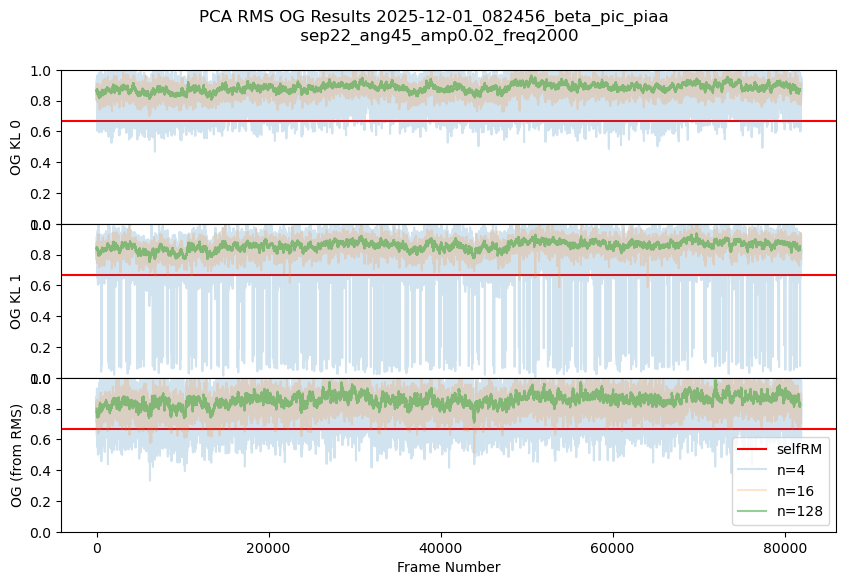

In [105]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,6), facecolor='white', sharex=True)
fig.subplots_adjust(hspace=0)
plt.suptitle(f"PCA RMS OG Results {sparkPCA.obs_string} \n {sparkPCA.calib_folder}")

og_res = sparkPCA.og_rms(dot_results, n_avg=4)
og_res_16 = sparkPCA.og_rms(dot_results, n_avg=16)
og_res_128 = sparkPCA.og_rms(dot_results, n_avg=128)

for i in range(og_res.shape[0]):
    axs[i].axhline(og_selfrm, c="red", label="selfRM")
    axs[i].plot(og_res[i], label=f"n=4", alpha=0.2)
    axs[i].plot(og_res_16[i], label=f"n=16", alpha=0.2)
    axs[i].plot(og_res_128[i], label=f"n=128", alpha=0.5)
    axs[i].set_ylim(0, 1.0)
    axs[i].set_ylabel(f"OG KL {i}")

plt.xlabel("Frame Number")
plt.ylabel("OG (from RMS)")
plt.legend()
plt.show()

In [87]:
og_res_16.shape

(3, 16368)

### old

In [5]:
# TODO: update these for the most recent ones
dark_dir = '/opt/MagAOX/calib/camwfs-dark/'
lab_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_10.000000_-45.000000__T20240330051127513106835.fits'
sky_dark = dark_dir + 'camwfs-dark_bin2_1800.000000_600.000000_-45.000000__T20240324234326026219038.fits'

reload(spca)
sparkPCA = spca.SparkXrif(sky_dark, lab_dark, spca.glob_dir_calib, spca.glob_mask, spca.glob_ref)

In [6]:
# then, we're going to disect the two folders I'm thinking of
obs_str_test = "2025-12-03_052203_beta_pic_piaa"
sky_dt, sky_obs = dir_to_lookyloo(obs_str_test)
print(sky_dt, sky_obs)

lab_str_test = "2025-12-03_042134_tau_ceti_lab_efc_unsats"
lab_dt, lab_obs = dir_to_lookyloo(lab_str_test, target_name="tau_ceti")
print(lab_dt, lab_obs)

2025-12-03 05:22:03+00:00 piaa
2025-12-03 04:21:34+00:00 lab_efc_unsats


In [7]:
# looking at the offset tweeter speck frames 
sparkPCA.set_data(sky_obs, lab_obs, sky_dt, lab_dt)

['0:11:54.416477 \n', '0:00:36.704347 \n', '1:41:43.488952 \n', '0:05:13.108249 \n', '0:05:06.298919 \n', '0:41:52.140625 \n', '0:05:13.880199 \n', '0:05:01.180729 \n', '0:02:59.902150 \n', '0:05:14.799356 \n', '0:01:22.063232 \n', '0:54:21.446229 \n', '0:02:04.315882 \n', '0:18:22.113603 \n', '0:05:38.846313 \n', '0:05:50.483306 \n', '0:03:22.137872 \n', '0:08:43.860726 \n', '0:57:41.425245 \n', '0:19:17.800305 \n', '0:05:06.029884 \n', '0:04:02.644722 \n', '0:02:20.588059 \n', '0:02:20.831095 \n', '0:00:57.755708 \n', '0:00:55.077337 \n', '0:00:44.271515 \n', '0:00:53.801453 \n', '0:00:36.895923 \n', '0:00:54.449253 \n', '0:00:40.595930 \n', '0:01:30.716127 \n', '0:02:08.139685 \n', '0:00:57.304783 \n', '0:02:23.744307 \n', '0:06:16.158847 \n', '0:02:23.551894 \n', '0:03:37.353735 \n', '0:00:54.954098 \n', '0:01:22.320116 \n', '0:00:42.396378 \n', '0:00:25.359113 \n', '0:00:33.400075 \n', '0:03:09.816301 \n', '0:05:02.539053 \n', '0:01:57.178315 \n', '0:01:01.501172 \n', '0:01:34.250

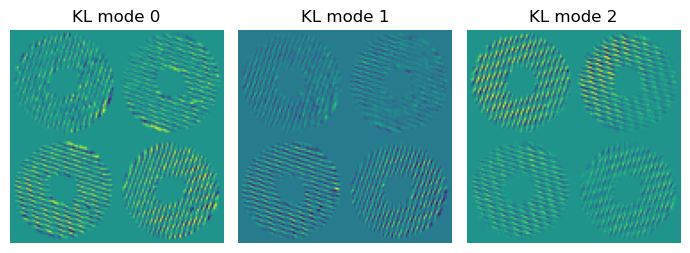

In [16]:
Z_KL_lab_images = sparkPCA.ref_pca_img
plt.figure(figsize=(7, 3))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"KL mode {i}")
    plt.imshow(Z_KL_lab_images[i])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.box(False)
#plt.suptitle(f"KL modes \n {obs_plot_name} {lab_name}")
plt.tight_layout()
plt.show()

In [9]:
dot_results = sparkPCA.proj_pool(n = 1000)

[TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052203614112000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 3, 614112, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052207710112000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 7, 710112, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052211806116000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 11, 806116, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052215902118000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 15, 902118, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052219998120000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 19, 998120, tzinfo=datetime.timezone.utc)), TimestampedFile(

chunksize=1, n_workers=4
(8192, 120, 120)(8192, 120, 120)

(8192, 3)
(8192, 3)


In [10]:
data_proj = np.vstack(dot_results)

In [11]:
data_proj

array([[ 2.75077151e-08,  4.06422541e-08,  3.95980247e-08],
       [ 5.55367356e-08, -4.74809315e-08, -2.40837777e-08],
       [-2.66499800e-08,  4.80102649e-08, -2.89101619e-08],
       ...,
       [ 6.08082326e-08, -5.16751543e-08, -2.08874945e-08],
       [-2.11240916e-08,  5.01052209e-08, -2.27391424e-08],
       [-7.50601889e-08, -3.74452050e-08,  1.84050260e-08]],
      shape=(16384, 3))

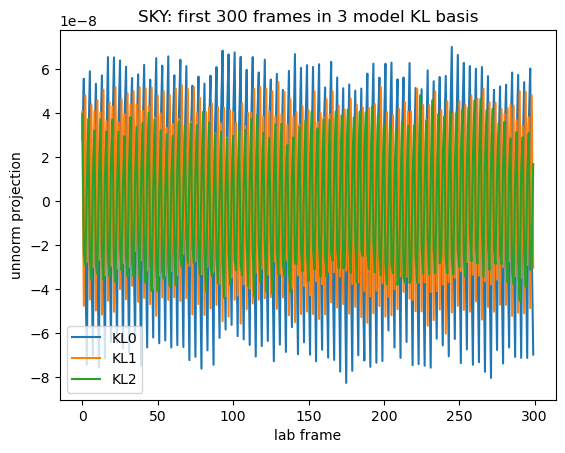

In [15]:
n = 300
plt.title(f"SKY: first {n} frames in 3 model KL basis")
for i in range(3):
    plt.plot(data_proj[:n,i], label=f"KL{i}")
plt.xlabel("lab frame")
plt.ylabel("unnorm projection")
plt.legend()
plt.show()

In [14]:
sparkPCA.ref_proj

array([[-2.86838526e-07,  4.79424850e-07, -3.75924604e-07],
       [-7.19422002e-07, -4.60414037e-07,  1.59819281e-07],
       [ 3.12319081e-07,  4.72943258e-07,  3.73246216e-07],
       [ 6.93941472e-07, -4.91953952e-07, -1.57140535e-07]])

In [75]:
n = data_proj.shape[0]
extended_divisor = np.array([np.repeat(sparkPCA.ref_proj[:,i].reshape(1,4), (n//4+1), axis=0).flatten()[:n] for i in range(3)]).T

In [73]:
extended_divisor.shape

(3, 16384)

In [80]:
data_proj / np.roll(extended_divisor, shift = 0, axis=0)

array([[-0.09589965,  0.08477294, -0.10533502],
       [-0.07719633,  0.10312659, -0.15069382],
       [-0.08532934,  0.10151379, -0.07745601],
       ...,
       [-0.08452373,  0.11223627, -0.13069446],
       [-0.06763625,  0.10594341, -0.06092263],
       [-0.10816501,  0.07611526, -0.11712462]], shape=(16384, 3))

In [62]:
extended_divisor

array([[-2.86838526e-07, -7.19422002e-07,  3.12319081e-07, ...,
        -7.19422002e-07,  3.12319081e-07,  6.93941472e-07],
       [ 4.79424850e-07, -4.60414037e-07,  4.72943258e-07, ...,
        -4.60414037e-07,  4.72943258e-07, -4.91953952e-07],
       [-3.75924604e-07,  1.59819281e-07,  3.73246216e-07, ...,
         1.59819281e-07,  3.73246216e-07, -1.57140535e-07]],
      shape=(3, 1000))

In [63]:
np.roll(extended_divisor, shift = -1, axis=1)

array([[-7.19422002e-07,  3.12319081e-07,  6.93941472e-07, ...,
         3.12319081e-07,  6.93941472e-07, -2.86838526e-07],
       [-4.60414037e-07,  4.72943258e-07, -4.91953952e-07, ...,
         4.72943258e-07, -4.91953952e-07,  4.79424850e-07],
       [ 1.59819281e-07,  3.73246216e-07, -1.57140535e-07, ...,
         3.73246216e-07, -1.57140535e-07, -3.75924604e-07]],
      shape=(3, 1000))

In [81]:
# I want the roll that minimizes the stdv
div_rolls = np.array([data_proj / np.roll(extended_divisor, shift = i, axis=0) for i in range(4)])

In [ ]:
div_rolls

In [ ]:
for i in range(3):
    plt.subplot(1,3,i)
    for i in range(4):
        plt.plot(div_rolls[i, :, 0])

In [ ]:
std_per_roll = np.std(div_rolls, axis=1) # minimized STD not consistent through rolls
mean_per_roll = np.mean(div_rolls, axis=1) # 

In [89]:
mean_per_roll

array([[-0.08720423,  0.08923442, -0.10646874],
       [-0.09095515, -0.08907271, -0.08905773],
       [ 0.08635279,  0.08862675,  0.10672797],
       [ 0.09180659, -0.08878847,  0.0887985 ]])

In [ ]:
def pick_roll(data_stack):
    '''
    Picks the roll from maximum average 
    '''
    data_allroll = np.array([split_data_dot_roll(data_stack, roll=i) for i in range(4)])
    roll_avgs = np.mean(data_allroll, axis = (1,2))
    roll_i = np.argmax(roll_avgs)
    print(f'Choosing roll index {roll_i}')
    dot_deroll = split_data_dot_roll(data_stack, roll=roll_i)
    return dot_deroll

In [55]:
# I need to make sure that I can select the right observation

# two ways to do this, put in a very specific time, or select wit the right start time

In [ ]:
# this funciton takes in an observation and turns it into a datetime


In [ ]:
lab_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_10.000000_-45.000000__T20240330051127513106835.fits'
sky_dark = dark_dir + 'camwfs-dark_bin2_1800.000000_600.000000_-45.000000__T20240324234326026219038.fits'
sky_obs_name = "piaa"
lab_obs_name = "lab_efc"

spca.SparkXrif(sky_obs_name, lab_obs_name, sky_dark, lab_dark, spca.glob_dir_calib, spca.glob_mask, spca.glob_ref)

NameError: name 'sky_dark' is not defined

## TEST 2: Lab references look good